##### NOTEBOOK 4 — MODELO LIGHTGBM
##### TFM: Integración QML en pipeline DataOps
##### Juan Albornoz Carrasco — Universidad Europea de Valencia
##### Lee desde Gold Parquet — Guarda modelo y métricas en Volumes


##### CELDA 1 — Instalación de dependencias
##### Ejecutar solo cuando las librerías no estén disponibles

In [0]:
#%pip install "numpy==1.23.5" lightgbm shap joblib
#%pip install skl2onnx onnx onnxruntime onnxmltools --quiet


##### CELDA 2 — Reinicio del kernel

In [0]:
dbutils.library.restartPython()

##### CELDA 3 — Imports

In [0]:
import os
import shap
import joblib
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import onnxruntime as rt
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.lightgbm.operator_converters.LightGbm import convert_lightgbm

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    matthews_corrcoef, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


In [0]:
gold_dir   = "/Volumes/workspace/default/nhanes/gold"
models_dir = "/Volumes/workspace/default/nhanes/models"
os.makedirs(models_dir, exist_ok=True)

##### CELDA 4 — Cargar datasets Gold

In [0]:
X_train = pd.read_parquet(f"{gold_dir}/X_train_lgbm.parquet")
X_test  = pd.read_parquet(f"{gold_dir}/X_test_lgbm.parquet")
y_train = pd.read_parquet(f"{gold_dir}/y_train_lgbm.parquet").squeeze()
y_test  = pd.read_parquet(f"{gold_dir}/y_test_lgbm.parquet").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribucion train: {y_train.value_counts().to_dict()}")
print(f"Distribucion test:  {y_test.value_counts().to_dict()}")

Train: (6264, 89), Test: (1567, 89)
Distribucion train: {0: 5385, 1: 879}
Distribucion test:  {0: 1347, 1: 220}


##### CELDA 5 — Calcular scale_pos_weight
##### Ajuste por desbalance de clases 86/14

In [0]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Negativos (0): {n_neg}")
print(f"Positivos (1): {n_pos}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Negativos (0): 5385
Positivos (1): 879
scale_pos_weight: 6.1263


##### CELDA 6 — GridSearchCV 5-fold estratificado
##### Optimizacion de hiperparametros por AUC-ROC

In [0]:
print("Iniciando GridSearchCV... (puede tardar unos minutos)")

param_grid = {
    "n_estimators":  [100, 300, 500],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
}

lgbm_base = lgb.LGBMClassifier(
    class_weight="balanced",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores hiperparametros: {grid_search.best_params_}")
print(f"Mejor AUC-ROC CV: {grid_search.best_score_:.4f}")

Iniciando GridSearchCV... (puede tardar unos minutos)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Mejores hiperparametros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}
Mejor AUC-ROC CV: 0.9416


##### CELDA 7 — Entrenamiento modelo final

In [0]:
best_params = grid_search.best_params_

lgbm_final = lgb.LGBMClassifier(
    **best_params,
    class_weight="balanced",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_final.fit(X_train, y_train)
print("Modelo LightGBM entrenado con mejores hiperparametros.")
print(f"Parametros: {best_params}")

Modelo LightGBM entrenado con mejores hiperparametros.
Parametros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}


##### CELDA 8 — Evaluacion sobre conjunto de test

In [0]:
y_pred       = lgbm_final.predict(X_test)
y_pred_proba = lgbm_final.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("=== METRICAS LIGHTGBM ===")
print(f"AUC-ROC:  {auc:.4f}")
print(f"F1-macro: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"MCC:      {mcc:.4f}")
print(f"\nReporte detallado:")
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))

=== METRICAS LIGHTGBM ===
AUC-ROC:  0.9485
F1-macro: 0.6523
Accuracy: 0.7243
MCC:      0.4566

Reporte detallado:
              precision    recall  f1-score   support

 No diabetes       0.99      0.69      0.81      1347
    Diabetes       0.33      0.96      0.49       220

    accuracy                           0.72      1567
   macro avg       0.66      0.82      0.65      1567
weighted avg       0.90      0.72      0.77      1567



##### CELDA 9 — Curva ROC

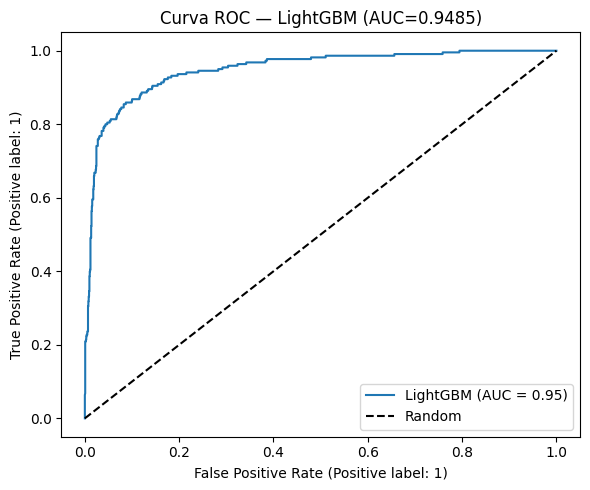

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax, name="LightGBM")
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title(f"Curva ROC — LightGBM (AUC={auc:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{models_dir}/roc_lgbm.png", dpi=150)
plt.show()

##### CELDA 10 — Matriz de confusion

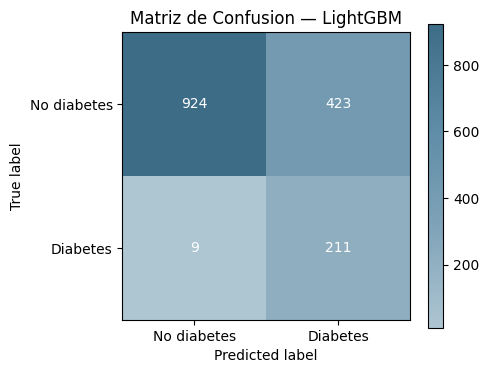

In [0]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import ConfusionMatrixDisplay

colores_hex = [
    "#AEC5D2", 
    "#7FA3B8", 
    "#5D8BA6", 
    "#3D6C87"
]
mi_paleta = LinearSegmentedColormap.from_list("mi_paleta_azul", colores_hex)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No diabetes", "Diabetes"],
    ax=ax, colorbar=True,
    cmap=mi_paleta,
    text_kw={"color": "white"} 
)
ax.set_title("Matriz de Confusion — LightGBM")
plt.tight_layout()
plt.savefig(f"{models_dir}/confusion_lgbm.png", dpi=150)
plt.show()

##### CELDA 11 — SHAP TreeExplainer
##### Interpretabilidad global del modelo

In [0]:
print("Calculando valores SHAP...")
explainer   = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values shape: {shap_vals.shape}")

Calculando valores SHAP...
SHAP values shape: (1567, 89)


##### CELDA 12 — SHAP Summary Plot (importancia global)

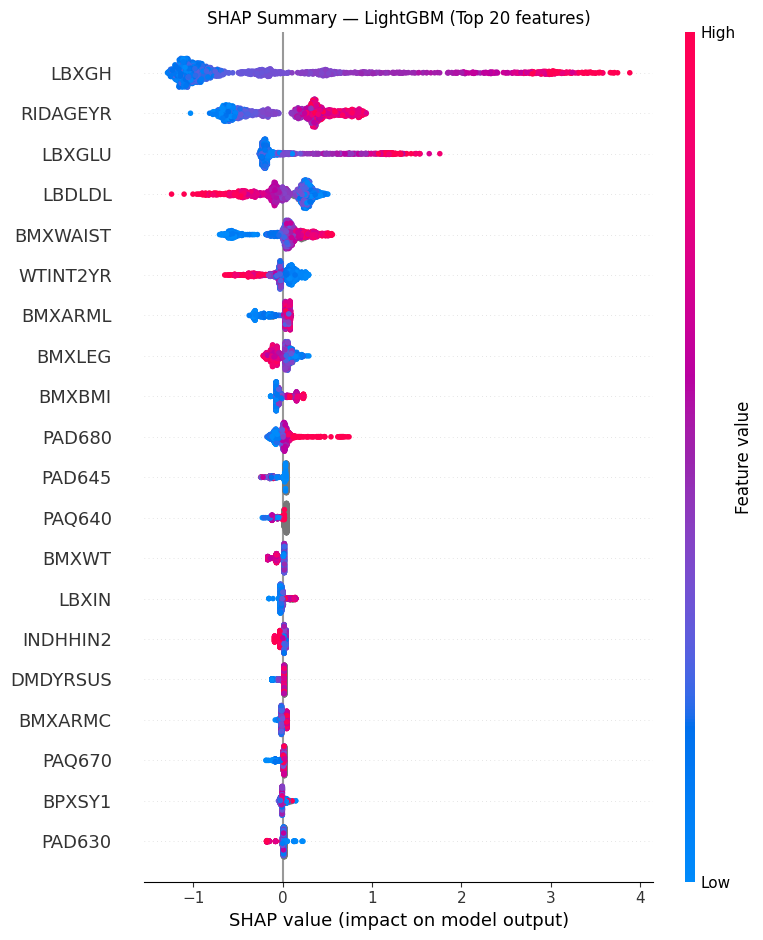

In [0]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test, max_display=20, show=False)
plt.title("SHAP Summary — LightGBM (Top 20 features)")
plt.tight_layout()
plt.savefig(f"{models_dir}/shap_summary_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

##### CELDA 13 — SHAP Bar Plot (importancia media absoluta)

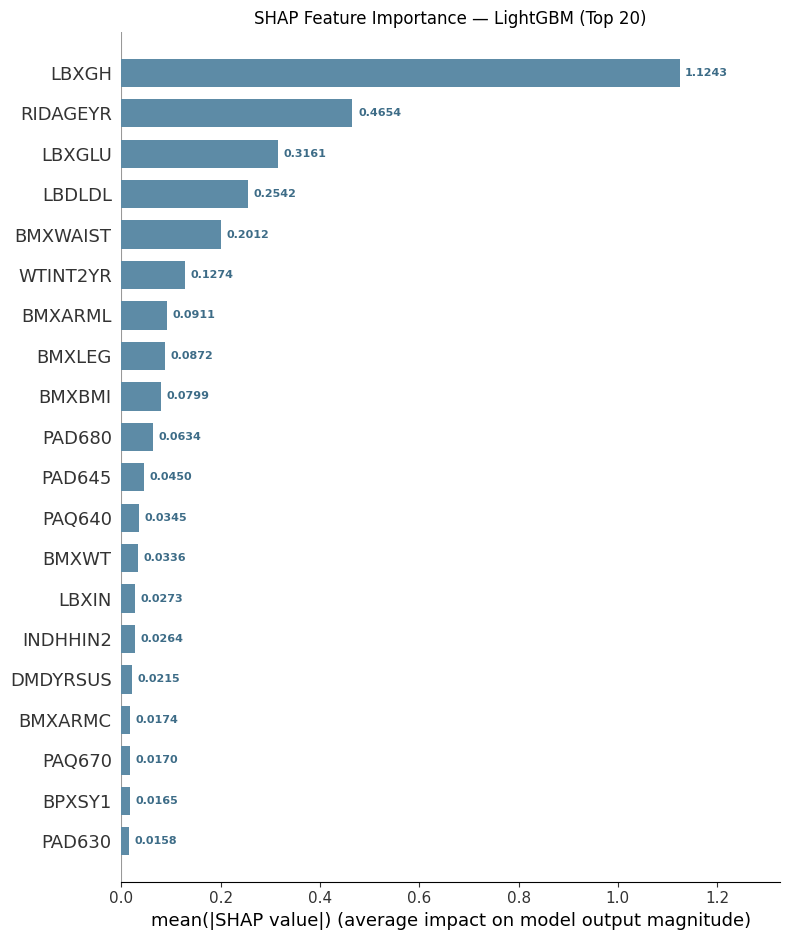

In [0]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_vals, 
    X_test, 
    plot_type="bar", 
    max_display=20, 
    show=False,
    color='#5D8BA6'
)

ax = plt.gca()
x_max = max(bar.get_width() for bar in ax.patches if bar.get_width() > 0)

for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width + x_max * 0.01,                # posición x: justo fuera de la barra
            bar.get_y() + bar.get_height() / 2,  # posición y: centro de la barra
            f'{width:.4f}',                       # valor con 4 decimales
            ha='left', va='center',
            fontsize=8,
            color='#3D6C87',
            fontweight='bold'
        )

# Ampliar eje x para que quepan los valores
ax.set_xlim(0, x_max * 1.18)

plt.title("SHAP Feature Importance — LightGBM (Top 20)")
plt.tight_layout()
plt.savefig(f"{models_dir}/shap_bar_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

##### CELDA 14 — Guardar modelo y metricas

In [0]:
# Guardar modelo
joblib.dump(lgbm_final, f"{models_dir}/lgbm_final.pkl")
print(f"Modelo guardado: {models_dir}/lgbm_final.pkl")

# Guardar metricas
metricas_lgbm = {
    "modelo":      "LightGBM",
    "auc_roc":     round(auc, 4),
    "f1_macro":    round(f1, 4),
    "accuracy":    round(acc, 4),
    "mcc":         round(mcc, 4),
    "best_params": best_params
}

pd.DataFrame([metricas_lgbm]).to_csv(f"{models_dir}/metricas_lgbm.csv", index=False)
print(f"Metricas guardadas: {models_dir}/metricas_lgbm.csv")
print("\nResumen final:")
print(metricas_lgbm)

Modelo guardado: /Volumes/workspace/default/nhanes/models/lgbm_final.pkl
Metricas guardadas: /Volumes/workspace/default/nhanes/models/metricas_lgbm.csv

Resumen final:
{'modelo': 'LightGBM', 'auc_roc': 0.9485, 'f1_macro': 0.6523, 'accuracy': 0.7243, 'mcc': 0.4566, 'best_params': {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}}


##### CELDA 15 — Serialización ONNX y verificación — LightGBM

In [0]:
# Registrar conversor LightGBM en skl2onnx
update_registered_converter(
    lgb.sklearn.LGBMClassifier,
    'LightGbmLGBMClassifier',
    calculate_linear_classifier_output_shapes,
    convert_lightgbm,
    options={'nocl': [True, False], 'zipmap': [True, False]}
)

# Convertir a ONNX
n_features    = X_train.shape[1]
initial_type  = [("float_input", FloatTensorType([None, n_features]))]
onnx_model    = convert_sklearn(
    lgbm_final,
    initial_types=initial_type,
    target_opset={'': 12, 'ai.onnx.ml': 3},
    options={lgb.sklearn.LGBMClassifier: {'zipmap': False}}
)

# Guardar
onnx_path = f"{models_dir}/lgbm_final.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Modelo ONNX guardado: {onnx_path}")
print(f"Tamaño: {os.path.getsize(onnx_path) / 1024:.1f} KB")

# Verificar consistencia PKL vs ONNX
rt.set_default_logger_severity(3)
sess       = rt.InferenceSession(onnx_path)
input_name = sess.get_inputs()[0].name
y_pred_onnx = sess.run(None, {input_name: X_test.values.astype(np.float32)})[0]

coincidencias = (y_pred_onnx == y_pred).mean()
print(f"\nCoincidencia PKL vs ONNX: {coincidencias*100:.1f}%")
print("ONNX verificado OK" if coincidencias == 1.0 else "⚠️ Diferencias detectadas")

Modelo ONNX guardado: /Volumes/workspace/default/nhanes/models/lgbm_final.onnx
Tamaño: 276.7 KB

Coincidencia PKL vs ONNX: 100.0%
ONNX verificado OK


##### CELDA 16 — Validacion final LightGBM

In [0]:
print("=== VALIDACION FINAL LIGHTGBM ===")
print(f"\n1. Modelo guardado:")
print(f"   {models_dir}/lgbm_final.pkl")

print(f"\n2. Metricas:")
df_check = pd.read_csv(f"{models_dir}/metricas_lgbm.csv")
print(df_check.to_string(index=False))

print(f"\n3. Graficos guardados:")
for f in ["roc_lgbm.png", "confusion_lgbm.png", "shap_summary_lgbm.png", "shap_bar_lgbm.png"]:
    exists = os.path.exists(f"{models_dir}/{f}")
    print(f"   {f}: {'OK' if exists else 'FALTA'}")

print("\n=== LIGHTGBM COMPLETADO OK ===")

=== VALIDACION FINAL LIGHTGBM ===

1. Modelo guardado:
   /Volumes/workspace/default/nhanes/models/lgbm_final.pkl

2. Metricas:
  modelo  auc_roc  f1_macro  accuracy    mcc                                                  best_params
LightGBM   0.9485    0.6523    0.7243 0.4566 {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}

3. Graficos guardados:
   roc_lgbm.png: OK
   confusion_lgbm.png: OK
   shap_summary_lgbm.png: OK
   shap_bar_lgbm.png: OK

=== LIGHTGBM COMPLETADO OK ===
